# 07 — NanoVLM Evaluation

The training stage is complete. We now evaluate whether the NanoVLM learned a useful shared image-text representation.

The main comparison is:

1. **Pre-training:** a freshly initialized NanoVLM with random weights.
2. **Post-training:** the trained NanoVLM loaded from the saved checkpoint.

The key question is:

> Did contrastive training make matching images and captions more similar?

The evaluation flow is:

```text
Image
  ↓
Image Encoder
  ↓
Image Embedding
  │
  ├──────────────→ Similarity
  │
  ↓
Shared 64-D Embedding Space
  ↑
  │
Text Embedding
  ↑
Text Encoder
  ↑
Caption

In [1]:
from pathlib import Path

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt


# --------------------------------------------------
# Device
# --------------------------------------------------

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", DEVICE)


# --------------------------------------------------
# Project / checkpoint paths
# --------------------------------------------------

project_root = Path.cwd().parent

checkpoints_dir = project_root / "checkpoints"

checkpoint_path = (
    checkpoints_dir / "nanovlm_checkpoint_new.pt"
)


assert checkpoint_path.exists(), (
    f"Checkpoint not found:\n{checkpoint_path}"
)

print("Checkpoint:", checkpoint_path)

Device: cpu
Checkpoint: d:\github\Build A NanoVLM From SCRATCH\checkpoints\nanovlm_checkpoint_new.pt


## 1. Load the Evaluation Batch

We evaluate both models using the **same batch of real image-caption pairs**.

This is important because it makes the comparison fair:

```text
Same images
Same captions
     │
     ├───────────────┐
     ↓               ↓
Random Model    Trained Model
     ↓               ↓
Pre-training    Post-training
embeddings      embeddings

# 01 Loading the data from previous Notebooks

Random seed: 42
Number of colors: 9
Number of shapes: 3
Number of positions: 9
Expected number of samples: 243
Number of combinations: 243
red circle top-left


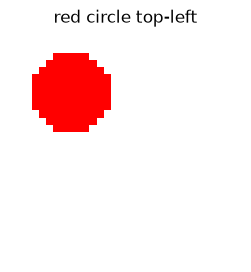

Total samples: 243


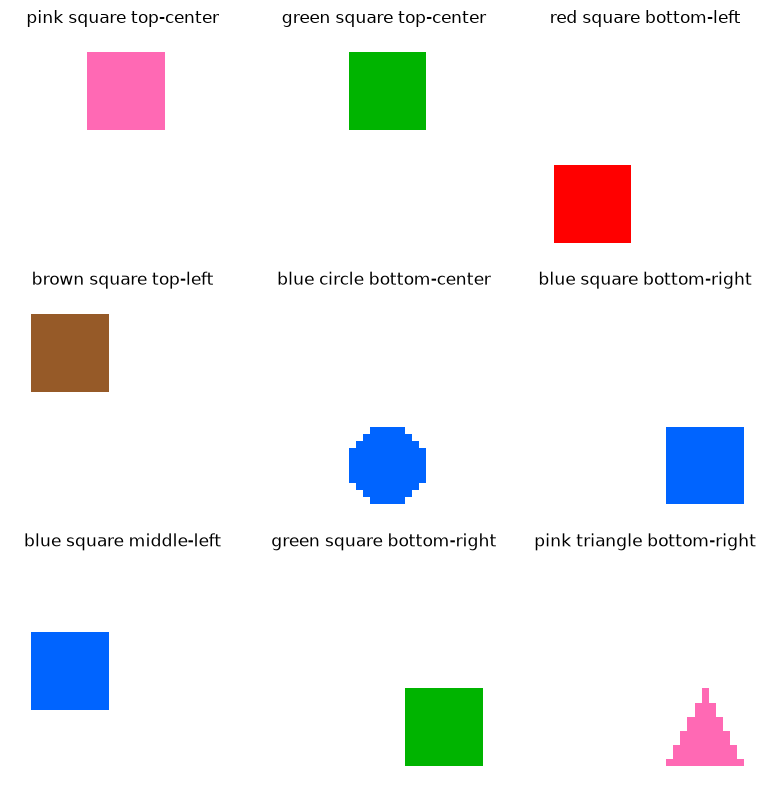

Unique colors: 9
Unique shapes: 3
Unique positions: 9
Unique combinations: 243
✓ Dataset coverage verified.
Total samples: 243
Training samples: 194
Validation samples: 49
Train: 194 samples
Validation: 49 samples
Training dataset: 194
Validation dataset: 49
Image shape: torch.Size([3, 32, 32])
Caption: green triangle top-left
Color: green
Shape: triangle
Position: top-left
Train batches: 7
Validation batches: 2
Image batch shape: torch.Size([32, 3, 32, 32])
Number of captions: 32

First five captions:
- yellow circle bottom-left
- brown circle top-left
- purple circle top-left
- brown triangle center
- blue square center


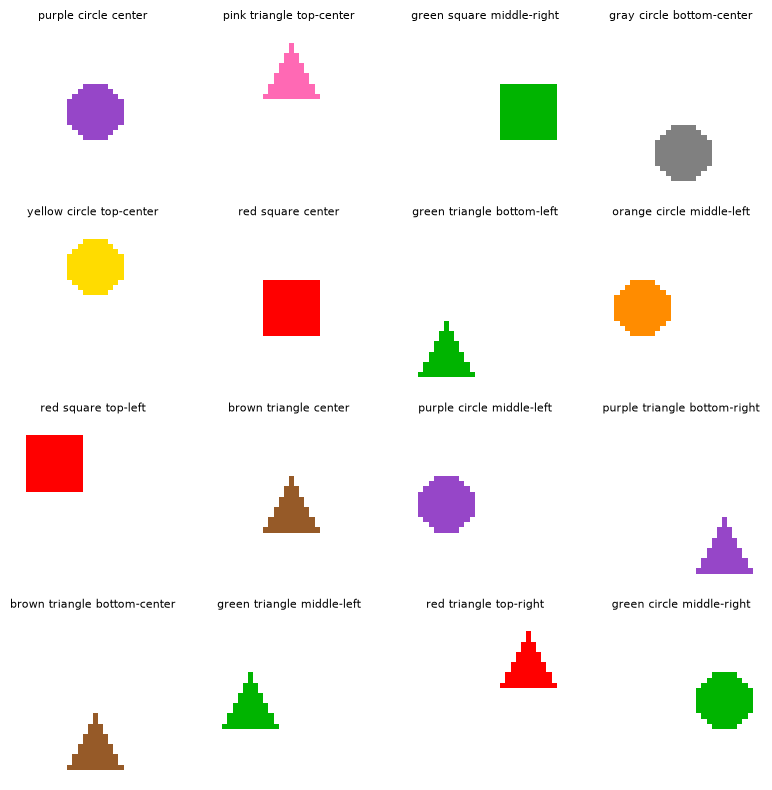

NanoVLM Synthetic Dataset
Total samples       : 243
Training samples    : 194
Validation samples  : 49
Image size          : 32 x 32
Colors              : 9
Shapes              : 3
Positions           : 9
Expected combinations: 243

✓ Dataset notebook completed successfully.
Random seed: 42
Number of colors: 9
Number of shapes: 3
Number of positions: 9
Expected number of samples: 243
Number of combinations: 243
red circle top-left


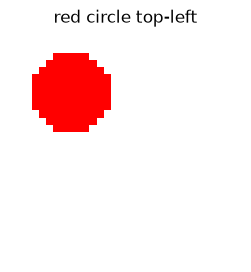

Total samples: 243


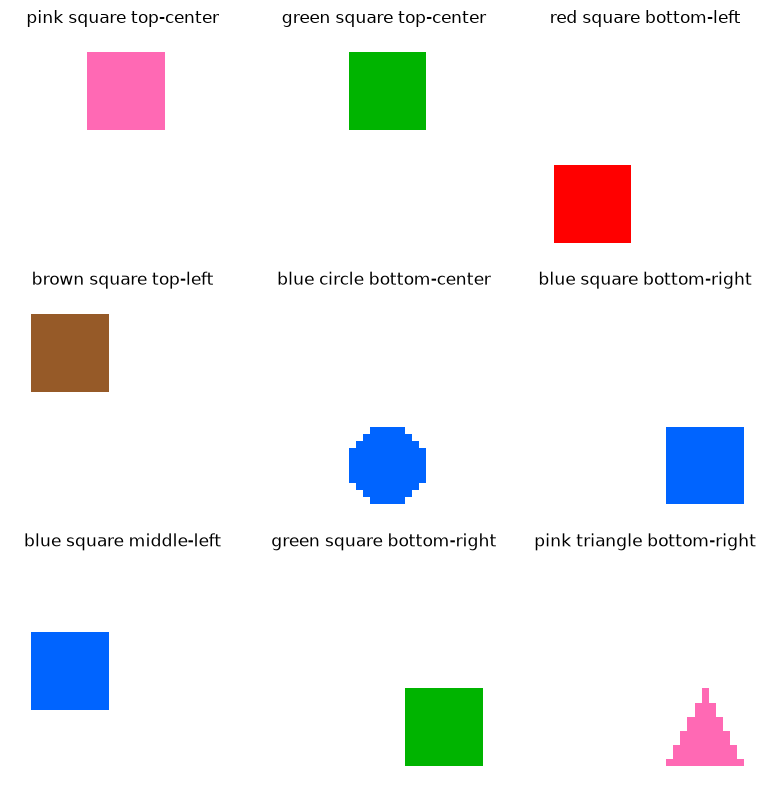

Unique colors: 9
Unique shapes: 3
Unique positions: 9
Unique combinations: 243
✓ Dataset coverage verified.
Total samples: 243
Training samples: 194
Validation samples: 49
Train: 194 samples
Validation: 49 samples
Training dataset: 194
Validation dataset: 49
Image shape: torch.Size([3, 32, 32])
Caption: green triangle top-left
Color: green
Shape: triangle
Position: top-left
Train batches: 7
Validation batches: 2
Image batch shape: torch.Size([32, 3, 32, 32])
Number of captions: 32

First five captions:
- yellow circle bottom-left
- brown circle top-left
- purple circle top-left
- brown triangle center
- blue square center


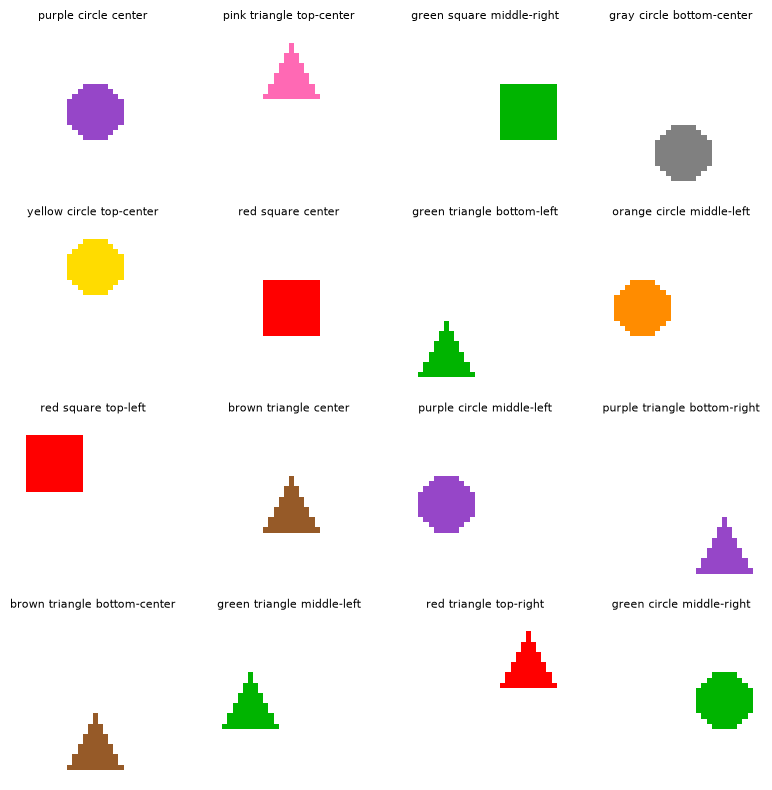

NanoVLM Synthetic Dataset
Total samples       : 243
Training samples    : 194
Validation samples  : 49
Image size          : 32 x 32
Colors              : 9
Shapes              : 3
Positions           : 9
Expected combinations: 243

✓ Dataset notebook completed successfully.
ImageEncoder(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (global_pool): AdaptiveAvgPool2d(output_size=1)
  (projection): Linear(in_features=256, out_features=64, bias=True)
)
Input shape: torch.Size([4, 3, 32, 32])
Embedding shape: torch.Size([4, 64])
✓ Output shape is correct.
Input:                   torch.Size([4, 3, 32, 32])
After Conv 1:            torch.Size([4, 32, 16, 16])
After Conv 2:            torch.Size([4, 64, 8, 8])
After Conv 3:       

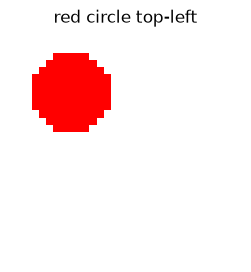

Total samples: 243


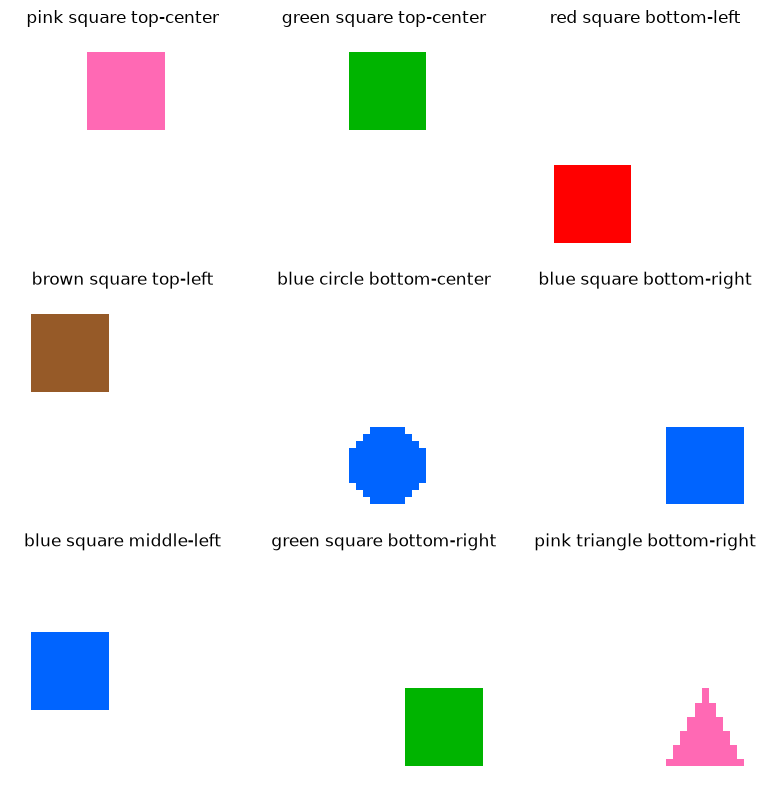

Unique colors: 9
Unique shapes: 3
Unique positions: 9
Unique combinations: 243
✓ Dataset coverage verified.
Total samples: 243
Training samples: 194
Validation samples: 49
Train: 194 samples
Validation: 49 samples
Training dataset: 194
Validation dataset: 49
Image shape: torch.Size([3, 32, 32])
Caption: green triangle top-left
Color: green
Shape: triangle
Position: top-left
Train batches: 7
Validation batches: 2
Image batch shape: torch.Size([32, 3, 32, 32])
Number of captions: 32

First five captions:
- yellow circle bottom-left
- brown circle top-left
- purple circle top-left
- brown triangle center
- blue square center


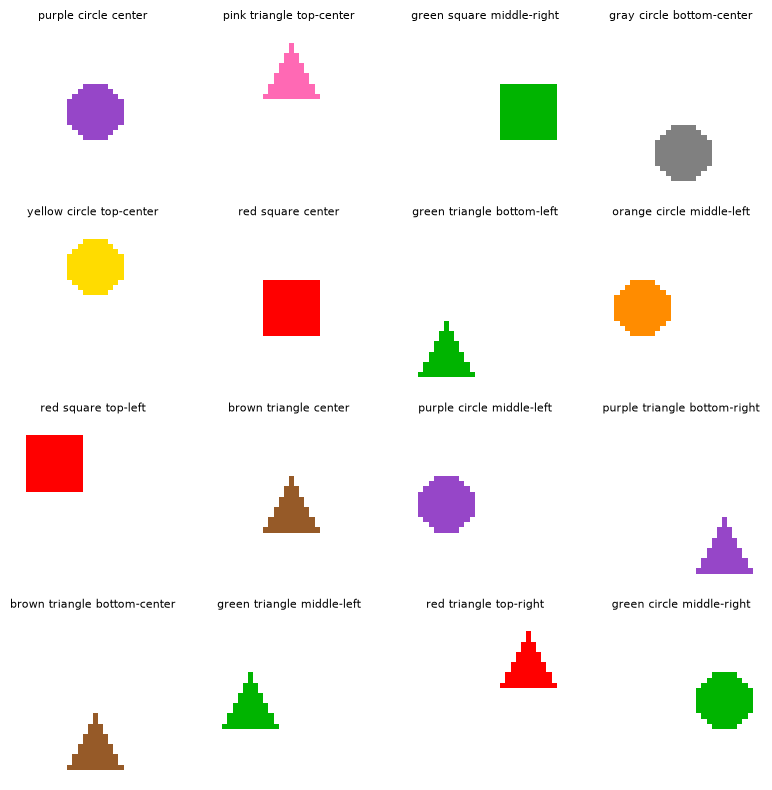

NanoVLM Synthetic Dataset
Total samples       : 243
Training samples    : 194
Validation samples  : 49
Image size          : 32 x 32
Colors              : 9
Shapes              : 3
Positions           : 9
Expected combinations: 243

✓ Dataset notebook completed successfully.
Batch type: <class 'dict'>
Images shape: torch.Size([32, 3, 32, 32])
Number of captions: 32
First caption: yellow triangle center
Token shape: torch.Size([32, 16])
Token dtype: torch.int64
Token device: cpu
Tokens shape:            torch.Size([32, 16])
Text embeddings shape:  torch.Size([32, 64])
Text embeddings dtype:  torch.float32
Text embeddings device: cpu
✓ Real captions successfully passed through the Text Encoder.
Random seed: 42
Number of colors: 9
Number of shapes: 3
Number of positions: 9
Expected number of samples: 243
Number of combinations: 243
red circle top-left


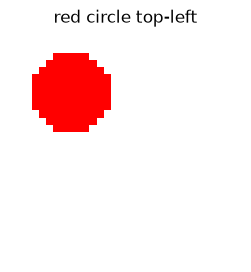

Total samples: 243


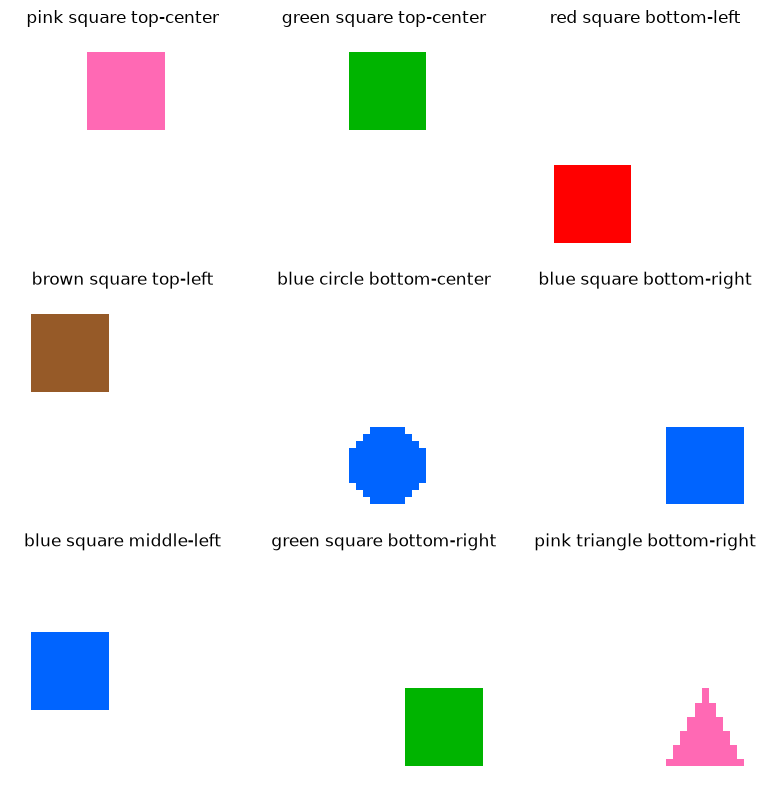

Unique colors: 9
Unique shapes: 3
Unique positions: 9
Unique combinations: 243
✓ Dataset coverage verified.
Total samples: 243
Training samples: 194
Validation samples: 49
Train: 194 samples
Validation: 49 samples
Training dataset: 194
Validation dataset: 49
Image shape: torch.Size([3, 32, 32])
Caption: green triangle top-left
Color: green
Shape: triangle
Position: top-left
Train batches: 7
Validation batches: 2
Image batch shape: torch.Size([32, 3, 32, 32])
Number of captions: 32

First five captions:
- yellow circle bottom-left
- brown circle top-left
- purple circle top-left
- brown triangle center
- blue square center


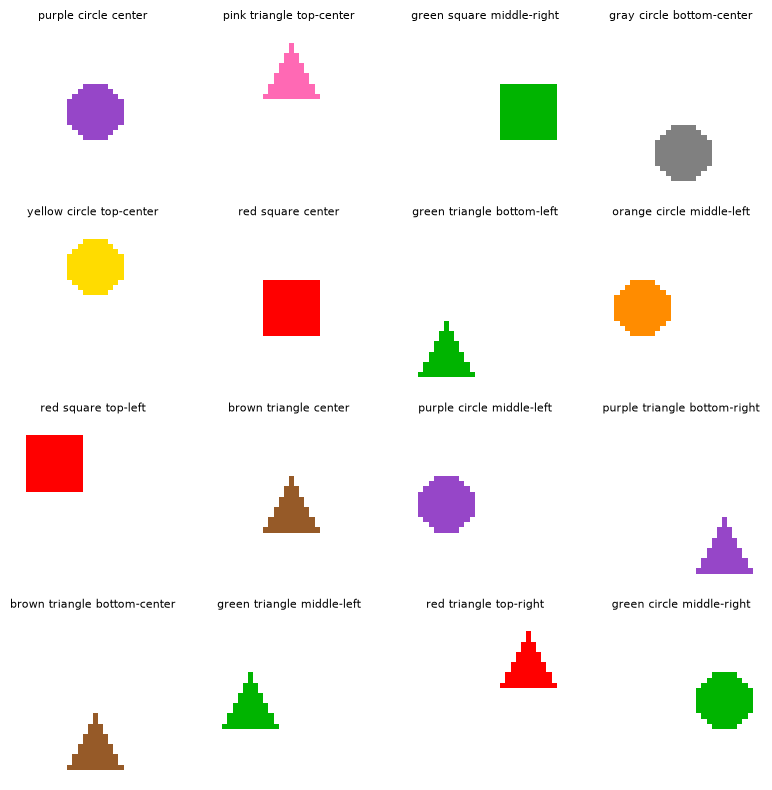

NanoVLM Synthetic Dataset
Total samples       : 243
Training samples    : 194
Validation samples  : 49
Image size          : 32 x 32
Colors              : 9
Shapes              : 3
Positions           : 9
Expected combinations: 243

✓ Dataset notebook completed successfully.
ImageEncoder(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (global_pool): AdaptiveAvgPool2d(output_size=1)
  (projection): Linear(in_features=256, out_features=64, bias=True)
)
Input shape: torch.Size([4, 3, 32, 32])
Embedding shape: torch.Size([4, 64])
✓ Output shape is correct.
Input:                   torch.Size([4, 3, 32, 32])
After Conv 1:            torch.Size([4, 32, 16, 16])
After Conv 2:            torch.Size([4, 64, 8, 8])
After Conv 3:       

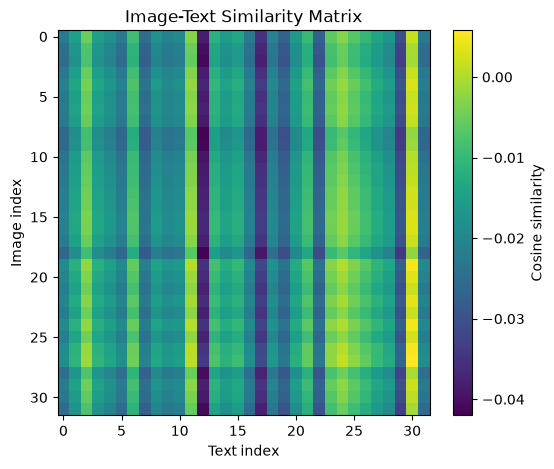

Temperature: 0.07
Logits shape: torch.Size([32, 32])
Labels: tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31])
Image-to-text loss: 3.474287509918213
Text-to-image loss: 3.466135025024414
Image-to-text loss: 3.474287509918213
Text-to-image loss: 3.466135025024414
Symmetric CLIP loss: 3.4702112674713135
CLIPContrastiveLoss()
Image-to-text loss: 3.474287509918213
Text-to-image loss: 3.466135025024414
Total CLIP loss: 3.4702112674713135
Similarity shape: torch.Size([32, 32])
Toy similarity matrix:
tensor([[1., 0.],
        [0., 1.]])

Toy logits:
tensor([[10.,  0.],
        [ 0., 10.]])

Labels:
tensor([0, 1])

Image-to-text loss:
4.541770613286644e-05

Text-to-image loss:
4.541770613286644e-05

Symmetric loss:
4.541770613286644e-05
Manual loss: 4.541770613286644e-05
Class loss : 4.541770613286644e-05
✓ Manual and class implementations match.
✓ Embedding shapes are correct.
✓ Similarity matrix sh

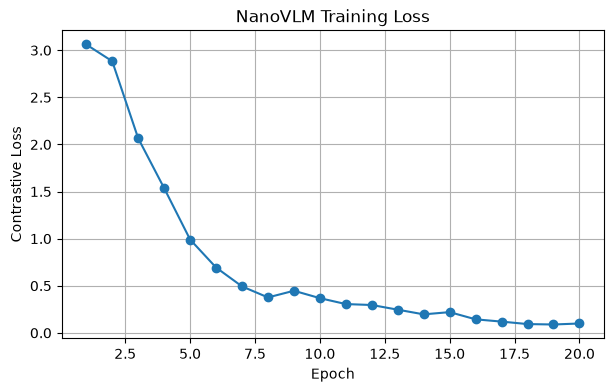

NanoVLM checkpoint saved successfully!
Path: d:\github\Build A NanoVLM From SCRATCH\checkpoints\nanovlm_checkpoint_new.pt
Size: 5045.37 KB
Images: torch.Size([32, 3, 32, 32])
Image embeddings: torch.Size([32, 64])
Text embeddings: torch.Size([32, 64])
Similarity matrix: torch.Size([32, 32])


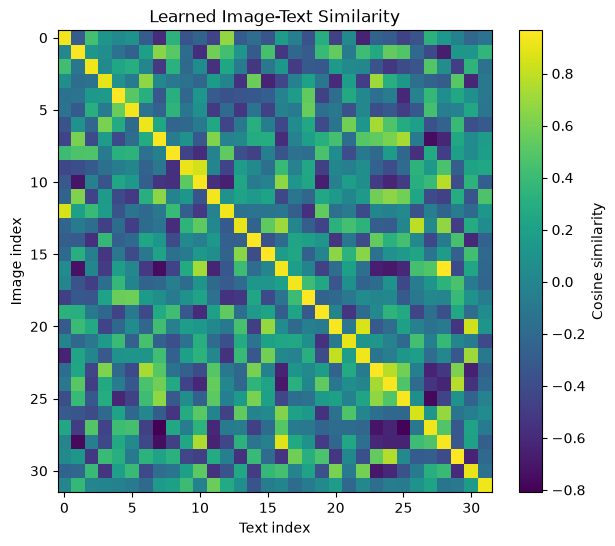

Image index: 0
Predicted caption index: 0
Actual matching caption index: 0
Predicted caption: brown circle center
Actual caption: brown circle center
Predicted similarity: 0.9321315884590149
Correct-pair similarity: 0.9321315884590149
Image index: 1
Predicted caption index: 1
Actual matching caption index: 1
Predicted caption: red square top-left
Actual caption: red square top-left
Predicted similarity: 0.9565806984901428
Correct-pair similarity: 0.9565806984901428
Image index: 2
Predicted caption index: 2
Actual matching caption index: 2
Predicted caption: pink circle middle-left
Actual caption: pink circle middle-left
Predicted similarity: 0.9285673499107361
Correct-pair similarity: 0.9285673499107361
Image index: 3
Predicted caption index: 3
Actual matching caption index: 3
Predicted caption: orange triangle middle-left
Actual caption: orange triangle middle-left
Predicted similarity: 0.9019447565078735
Correct-pair similarity: 0.9019447565078735
Image index: 4
Predicted caption ind

In [2]:
%run 05_Training.ipynb

In [3]:

if "val_loader" in globals():
    eval_loader = val_loader
elif "valid_loader" in globals():
    eval_loader = valid_loader
else:
    eval_loader = train_loader


# --------------------------------------------------
# Get one real evaluation batch
# --------------------------------------------------

batch = next(iter(eval_loader))

images, text_data = unpack_batch(batch)

tokens = prepare_text(text_data)


# --------------------------------------------------
# Move tensors to the evaluation device
# --------------------------------------------------

images = images.to(DEVICE)
tokens = tokens.to(DEVICE)


print("Images shape:", images.shape)
print("Tokens shape:", tokens.shape)
print("Image dtype:", images.dtype)
print("Token dtype:", tokens.dtype)
print("Image device:", images.device)
print("Token device:", tokens.device)

Images shape: torch.Size([32, 3, 32, 32])
Tokens shape: torch.Size([32, 16])
Image dtype: torch.float32
Token dtype: torch.int64
Image device: cpu
Token device: cpu


## 2. Load Pre-Training and Post-Training Models

We now create two versions of the same NanoVLM architecture.

### Pre-training model

This model is freshly initialized.

Its parameters are random, so it represents what the model looked like before learning from the image-text pairs.

### Post-training model

This model has exactly the same architecture, but its parameters are loaded from:

```text
checkpoints/nanovlm_checkpoint.pt

Random NanoVLM
      ↓
Pre-training representation


Trained NanoVLM
      ↓
Post-training representation

In [7]:
# Create a fresh model for the pre-training state
# --------------------------------------------------

pre_image_encoder = ImageEncoder()

pre_text_encoder = TextEncoder(
    vocab_size=VOCAB_SIZE,
    embed_dim=EMBED_DIM,
    max_length=CONTEXT_WINDOW,
    attention_heads=ATTENTION_HEADS,
    projection_dim=PROJECTION_DIM,
)

pre_model = NanoVLM(
    image_encoder=pre_image_encoder,
    text_encoder=pre_text_encoder,
).to(DEVICE)


# --------------------------------------------------
# Create another model for the trained state
# --------------------------------------------------

post_image_encoder = ImageEncoder()

post_text_encoder = TextEncoder(
    vocab_size=VOCAB_SIZE,
    embed_dim=EMBED_DIM,
    max_length=CONTEXT_WINDOW,
    attention_heads=ATTENTION_HEADS,
    projection_dim=PROJECTION_DIM,
)

post_model = NanoVLM(
    image_encoder=post_image_encoder,
    text_encoder=post_text_encoder,
).to(DEVICE)


# --------------------------------------------------
# Load trained checkpoint
# --------------------------------------------------

checkpoint = torch.load(
    checkpoint_path,
    map_location=DEVICE,
)

post_model.load_state_dict(
    checkpoint["model_state_dict"]
)


# --------------------------------------------------
# Evaluation mode
# --------------------------------------------------

pre_model.eval()
post_model.eval()


print("Pre-training model: randomly initialized")
print("Post-training model: checkpoint loaded")

if "epoch" in checkpoint:
    print("Checkpoint epoch:", checkpoint["epoch"])

Pre-training model: randomly initialized
Post-training model: checkpoint loaded
Checkpoint epoch: 20


## 3. Extract Pre-Training and Post-Training Embeddings

We now pass the **exact same batch** through both models.

For each model we obtain:

```text
Images
  ↓
Image Encoder
  ↓
Image Embeddings

In [8]:
# Extract embeddings
# --------------------------------------------------

with torch.no_grad():

    # Pre-training / random model
    pre_image_embeddings, pre_text_embeddings = (
        pre_model(images, tokens)
    )

    # Post-training / trained model
    post_image_embeddings, post_text_embeddings = (
        post_model(images, tokens)
    )


# --------------------------------------------------
# L2 normalize
# --------------------------------------------------

pre_image_embeddings = F.normalize(
    pre_image_embeddings,
    dim=-1,
)

pre_text_embeddings = F.normalize(
    pre_text_embeddings,
    dim=-1,
)

post_image_embeddings = F.normalize(
    post_image_embeddings,
    dim=-1,
)

post_text_embeddings = F.normalize(
    post_text_embeddings,
    dim=-1,
)


# --------------------------------------------------
# Verify embedding dimensions
# --------------------------------------------------

print(
    "Pre-training image embeddings:",
    pre_image_embeddings.shape,
)

print(
    "Pre-training text embeddings:",
    pre_text_embeddings.shape,
)

print(
    "Post-training image embeddings:",
    post_image_embeddings.shape,
)

print(
    "Post-training text embeddings:",
    post_text_embeddings.shape,
)


assert pre_image_embeddings.ndim == 2
assert pre_text_embeddings.ndim == 2

assert post_image_embeddings.ndim == 2
assert post_text_embeddings.ndim == 2

assert pre_image_embeddings.shape[1] == 64
assert pre_text_embeddings.shape[1] == 64

assert post_image_embeddings.shape[1] == 64
assert post_text_embeddings.shape[1] == 64


# --------------------------------------------------
# Similarity matrices
# --------------------------------------------------

pre_similarity = (
    pre_image_embeddings
    @ pre_text_embeddings.T
)

post_similarity = (
    post_image_embeddings
    @ post_text_embeddings.T
)


print("\nPre-training similarity:", pre_similarity.shape)
print("Post-training similarity:", post_similarity.shape)


# --------------------------------------------------
# Matching-pair similarities
# --------------------------------------------------

pre_diagonal = torch.diag(pre_similarity)

post_diagonal = torch.diag(post_similarity)


print(
    "\nMean matching similarity — pre-training:",
    pre_diagonal.mean().item(),
)

print(
    "Mean matching similarity — post-training:",
    post_diagonal.mean().item(),
)

Pre-training image embeddings: torch.Size([32, 64])
Pre-training text embeddings: torch.Size([32, 64])
Post-training image embeddings: torch.Size([32, 64])
Post-training text embeddings: torch.Size([32, 64])

Pre-training similarity: torch.Size([32, 32])
Post-training similarity: torch.Size([32, 32])

Mean matching similarity — pre-training: -0.2774823307991028
Mean matching similarity — post-training: 0.9264184236526489


## 4. Pre-Training vs Post-Training Alignment

The similarity matrix tells us how strongly every image matches every caption.

For a batch of size $B$:

$$
S \in \mathbb{R}^{B \times B}
$$

The diagonal contains the correct image-caption pairs:

```text
          Captions
       0   1   2   3
     ┌───────────────
Img 0│ ✓
Img 1│     ✓
Img 2│         ✓
Img 3│             ✓

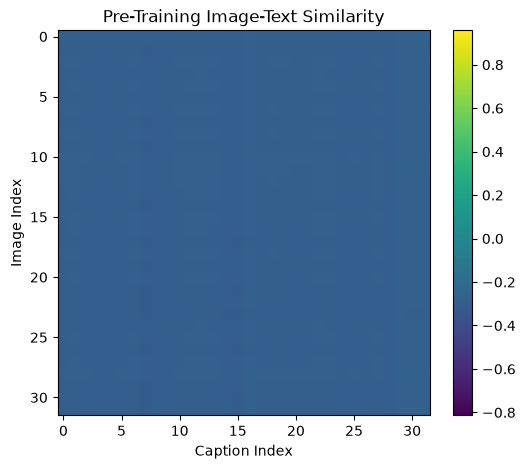

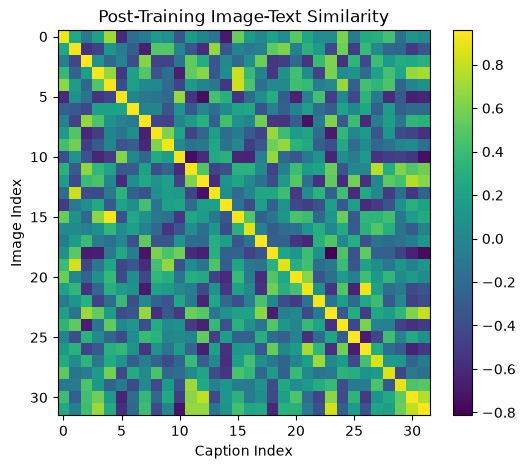

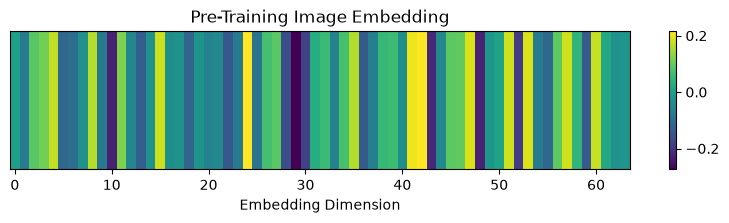

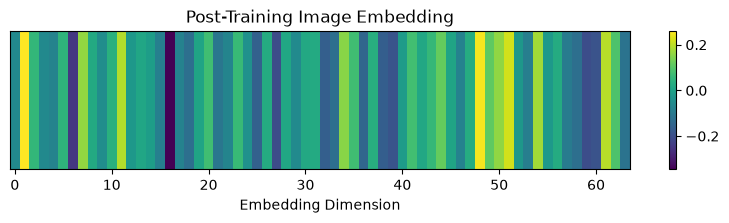

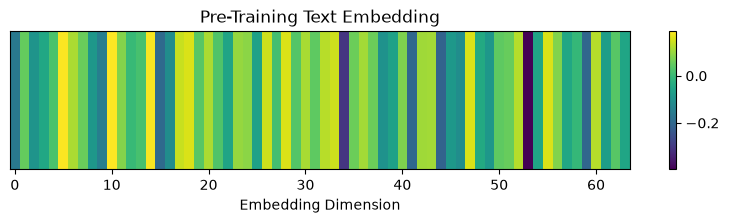

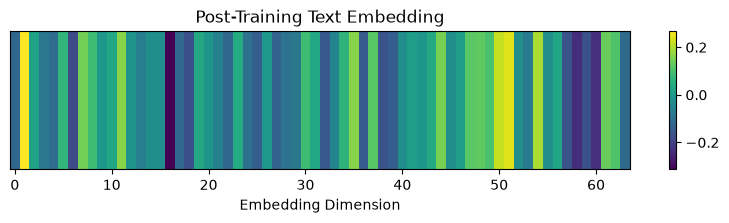

NanoVLM Evaluation Results
Mean matching similarity | Pre: -0.2775 | Post: 0.9264

Image → Text Top-1        | Pre: 3.12% | Post: 96.88%
Text → Image Top-1        | Pre: 3.12% | Post: 100.00%


In [11]:
# Similarity Matrix Visualization
# ==================================================

pre_sim = pre_similarity.cpu()
post_sim = post_similarity.cpu()

# Same scale for both plots
vmin = min(
    pre_sim.min().item(),
    post_sim.min().item(),
)

vmax = max(
    pre_sim.max().item(),
    post_sim.max().item(),
)


plt.figure(figsize=(6, 5))

plt.imshow(
    pre_sim,
    aspect="auto",
    vmin=vmin,
    vmax=vmax,
)

plt.colorbar()

plt.title(
    "Pre-Training Image-Text Similarity"
)

plt.xlabel("Caption Index")
plt.ylabel("Image Index")

plt.show()


plt.figure(figsize=(6, 5))

plt.imshow(
    post_sim,
    aspect="auto",
    vmin=vmin,
    vmax=vmax,
)

plt.colorbar()

plt.title(
    "Post-Training Image-Text Similarity"
)

plt.xlabel("Caption Index")
plt.ylabel("Image Index")

plt.show()


# ==================================================
# Embedding Vector Visualization
# ==================================================

sample_index = 0


embeddings_to_plot = [
    (
        pre_image_embeddings[sample_index],
        "Pre-Training Image Embedding",
    ),
    (
        post_image_embeddings[sample_index],
        "Post-Training Image Embedding",
    ),
    (
        pre_text_embeddings[sample_index],
        "Pre-Training Text Embedding",
    ),
    (
        post_text_embeddings[sample_index],
        "Post-Training Text Embedding",
    ),
]


for embedding, title in embeddings_to_plot:

    plt.figure(figsize=(10, 1.8))

    plt.imshow(
        embedding.detach()
        .cpu()
        .reshape(1, -1),
        aspect="auto",
    )

    plt.colorbar()

    plt.title(title)

    plt.xlabel("Embedding Dimension")

    plt.yticks([])

    plt.show()


# ==================================================
# Retrieval Metrics
# ==================================================

def top1_accuracy(similarity):
    """
    Image → Text Top-1 retrieval accuracy.
    """

    predictions = similarity.argmax(dim=1)

    targets = torch.arange(
        similarity.size(0),
        device=similarity.device,
    )

    return (
        predictions == targets
    ).float().mean().item()


def text_to_image_top1(similarity):
    """
    Text → Image Top-1 retrieval accuracy.
    """

    return top1_accuracy(similarity.T)


pre_i2t = top1_accuracy(pre_similarity)
post_i2t = top1_accuracy(post_similarity)

pre_t2i = text_to_image_top1(pre_similarity)
post_t2i = text_to_image_top1(post_similarity)


# ==================================================
# Final Results
# ==================================================

print("=" * 50)
print("NanoVLM Evaluation Results")
print("=" * 50)

print(
    f"Mean matching similarity | "
    f"Pre: {pre_diagonal.mean().item():.4f} | "
    f"Post: {post_diagonal.mean().item():.4f}"
)

print()

print(
    f"Image → Text Top-1        | "
    f"Pre: {pre_i2t:.2%} | "
    f"Post: {post_i2t:.2%}"
)

print(
    f"Text → Image Top-1        | "
    f"Pre: {pre_t2i:.2%} | "
    f"Post: {post_t2i:.2%}"
)

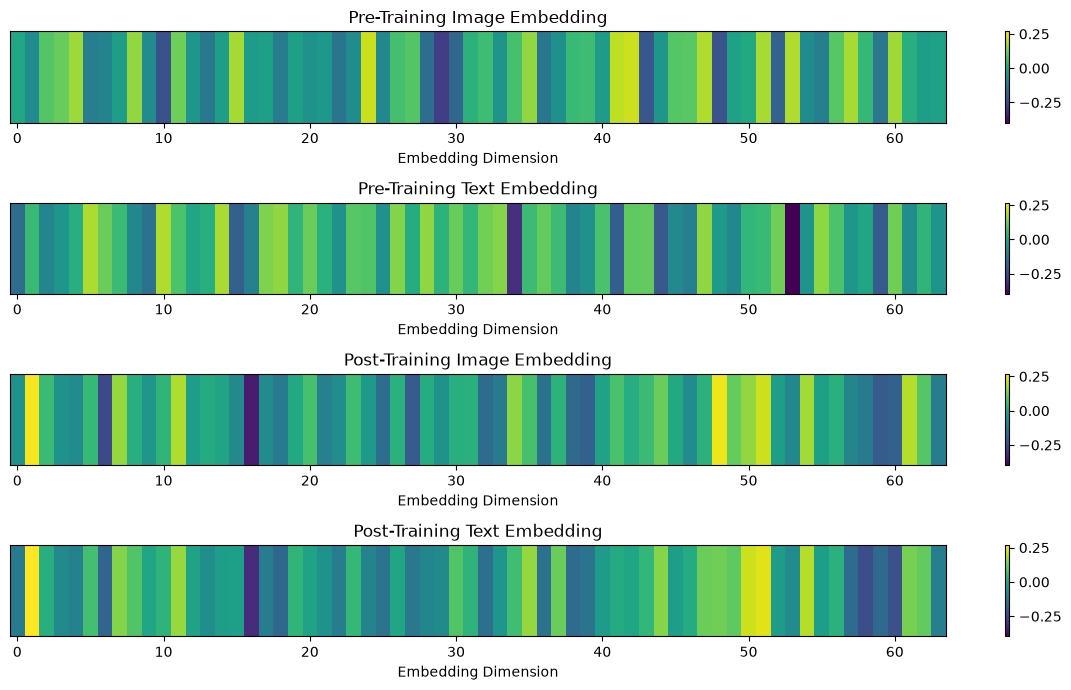

In [12]:
# ==================================================
# Pre-Training vs Post-Training Embeddings
# ==================================================

sample_index = 0

embeddings_to_plot = [
    (
        pre_image_embeddings[sample_index],
        "Pre-Training Image Embedding",
    ),
    (
        pre_text_embeddings[sample_index],
        "Pre-Training Text Embedding",
    ),
    (
        post_image_embeddings[sample_index],
        "Post-Training Image Embedding",
    ),
    (
        post_text_embeddings[sample_index],
        "Post-Training Text Embedding",
    ),
]


# Use one common scale so the four embeddings
# can be compared fairly.
all_values = torch.cat([
    embedding.detach().flatten()
    for embedding, _ in embeddings_to_plot
])

vmin = all_values.min().item()
vmax = all_values.max().item()


plt.figure(figsize=(12, 7))

for i, (embedding, title) in enumerate(
    embeddings_to_plot,
    start=1
):
    plt.subplot(4, 1, i)

    plt.imshow(
        embedding.detach()
        .cpu()
        .reshape(1, -1),
        aspect="auto",
        vmin=vmin,
        vmax=vmax,
    )

    plt.colorbar()

    plt.title(title)

    plt.xlabel("Embedding Dimension")
    plt.yticks([])


plt.tight_layout()
plt.show()